# Importing

In [94]:
import pandas as pd # Reading csv from pandas
import matplotlib.pyplot as plt # used for data visualization
import seaborn as sns # used for data visualization
from sklearn.model_selection import train_test_split # for spliting the data into train and test splits
from sklearn.svm import SVC # Model used
from sklearn.metrics import classification_report # to see model, accuracy, f1 score, recall, precision

# Dataset Information

* Dataset link: https://www.kaggle.com/datasets/ouline/student-mat-pass-or-fail
* The data set has 396 crows with 30 columns
1.  student's school (binary: 0 - Mousinho da Silveira or 1 - Gabriel Pereira)
2.  student's sex (binary: 0 - male or 1 - female)
3.  student's age (numeric: from 15 to 22)
4.  student's home address type (binary: 0 - rural or 1 - urban)
5.  family size (binary: 0 - greater than 3 or 1 - less or equal to 3 )
6.  parent's cohabitation status (binary: 0 - apart or 1 - living together)
7.  mother's education (numeric: 0 - none, 1 - primary education (4th grade), 2 - 5th to 9th grade, 3 - secondary education or 4 - higher education)
8.  father's education (numeric: 0 - none, 1 - primary education (4th grade), 2 - 5th to 9th grade, 3 - secondary education or 4 - higher education)
9.  home to school travel time (numeric: 1 -15 min., 2 - 15 to 30 min., 3 - 30 min. to 1 hour, or 4 - >1 hour)
10.  weekly study time (numeric: 1 - 2 hours, 2 - 2 to 5 hours, 3 - 5 to 10 hours, or 4 - >10 hours)
11.  number of past class failures (numeric: n if if 1<=n<3, else 4)
12.  extra educational support (binary: 0 - no or 1 - yes)
13.  family educational support (binary: 0 - no or 1 - yes)
14.  extra paid classes within the course subject (Math or Portuguese) (binary: 0 - no or 1 - yes)
15.  extra-curricular activities (binary: 0 - no or 1 - yes)
16.  attended nursery school (binary: 0 - no or 1 - yes)
17.  wants to take higher education (binary: 0 - no or 1 - yes)
18.  Internet access at home (binary: 0 - no or 1 - yes)
19.  with a romantic relationship (binary: 0 - no or 1 - yes)
20.  quality of family relationships (numeric: from 1 - very bad to 5 - excellent)
21.  free time after school (numeric: from 1 - very low to 5 - very high)
22.  going out with friends (numeric: from 1 - very low to 5 - very high)
23.  workday alcohol consumption (numeric: from 1 - very low to 5 - very high)
24.  weekend alcohol consumption (numeric: from 1 - very low to 5 - very high)
25.  current health status (numeric: from 1 - very bad to 5 - very good)
26.  number of school absences (numeric: from 0 to 93)
27.  first period grade (numeric: from 0 to 20)
28.  second period grade (numeric: from 0 to 20)
29.  final grade (numeric: from 0 to 20, output target)
30.  student mat pass or fail (binary: 0 - fail, 1 - pass)



In [80]:
df = pd.read_csv("/content/student-mat-pass-or-fail.csv")
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,traveltime,studytime,...,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3,pass
0,1,1,18,1,0,0,4,4,2,2,...,3,4,1,1,3,6,5,6,6,0
1,1,1,17,1,0,1,1,1,1,2,...,3,3,1,1,3,4,5,5,6,0
2,1,1,15,1,1,1,1,1,1,2,...,3,2,2,3,3,10,7,8,10,1
3,1,1,15,1,0,1,4,2,1,3,...,2,2,1,1,5,2,15,14,15,1
4,1,1,16,1,0,1,3,3,1,2,...,3,2,1,2,5,4,6,10,10,1


# EDA

In [81]:
print("Total number of rows: ", len(df))
print("total number of columns: ", len(df.columns.tolist()))
print("Name of columns: ", df.columns)
print("Number of passed candidates: ", len(df[df["pass"] == 1]))
print("Number of failed candidates: ", len(df[df["pass"] == 0]))
print("Number of Mousinho da Silveira school candidates: ", len(df[df["school"] == 0]))
print("Number of Gabriel Pereira school candidates: ", len(df[df["school"] == 1]))
print("Number of Male candidates: ", len(df[df["sex"] == 0]))
print("Number of Female candidates: ", len(df[df["sex"] == 1]))
print("Number of candidates with age greater then or equal 18: ", len(df[df["age"] >= 18]))
print("Number of rural candidates: ", len(df[df["address"] == 0]))
print("Number of urban candidates: ", len(df[df["address"] == 1]))
print("Number of candidates with family size greater than 3 or 1: ", len(df[df["famsize"] == 0]))
print("Number of candidates with family size less or equal to 3:  ", len(df[df["famsize"] == 1]))
print("Number of candidates living without their parents: ", len(df[df["Pstatus"] == 0]))
print("Number of candidates lliving with their parents parents: ", len(df[df["Pstatus"] == 1]))
print("Number of candidates whose mothers aren't educated: ", len(df[df["Medu"] == 0]))
print("Number of candidates whose mothers are educated: ", len(df[df["Medu"] != 0]))
print("Number of candidates whose fathers aren't educated: ", len(df[df["Fedu"] == 0]))
print("Number of candidates whose fathers are educated: ", len(df[df["Fedu"] != 0]))
print("Number of candidate with travel times more then 30 minutes: ", len(df[df["traveltime"] >= 3]))
print("Number of candidate with travel times less then 30 minutes: ", len(df[df["traveltime"] < 3]))
print("Number of missing values in the dataset: ", df.isnull().sum())

Total number of rows:  395
total number of columns:  30
Name of columns:  Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid',
       'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel',
       'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2',
       'G3', 'pass'],
      dtype='object')
Number of passed candidates:  265
Number of failed candidates:  130
Number of Mousinho da Silveira school candidates:  46
Number of Gabriel Pereira school candidates:  349
Number of Male candidates:  187
Number of Female candidates:  208
Number of candidates with age greater then or equal 18:  111
Number of rural candidates:  88
Number of urban candidates:  307
Number of candidates with family size greater than 3 or 1:  281
Number of candidates with family size less or equal to 3:   114
Number of candidates living without their parents:  41
Number of candidates lli

First period grade vs second period grade grouped by gender

Text(0.5, 1.0, 'First Period Grade vs Final Period Grade')

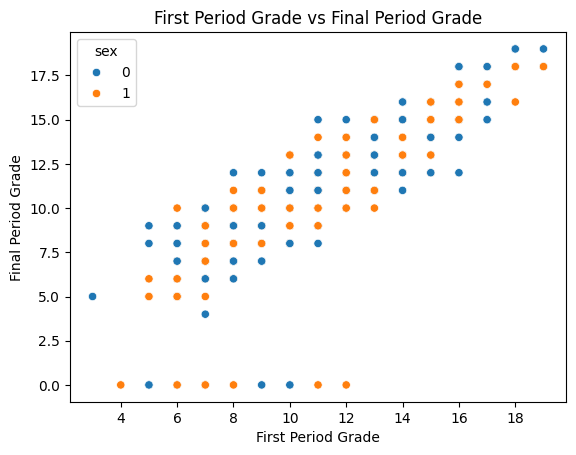

In [82]:
sns.scatterplot(data= df, x="G1", y="G2", hue="sex")
plt.xlabel("First Period Grade")
plt.ylabel("Final Period Grade")
plt.title("First Period Grade vs Final Period Grade")

First period grade vs final grade grouped by gender

Text(0.5, 1.0, 'First Period Grade vs Final Period Grade')

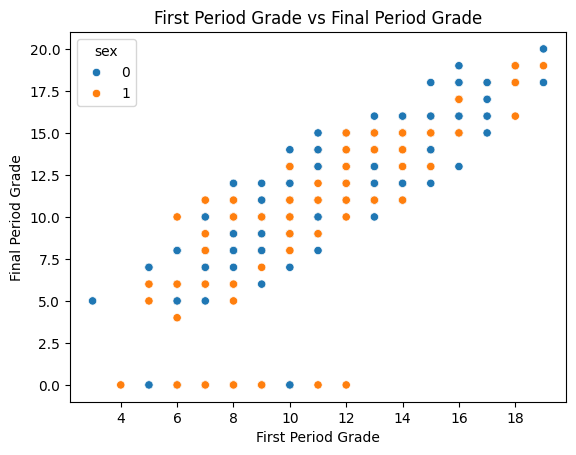

In [83]:
sns.scatterplot(data= df, x="G1", y="G3", color="pink", hue="sex")
plt.xlabel("First Period Grade")
plt.ylabel("Final Period Grade")
plt.title("First Period Grade vs Final Period Grade")

Second period grade vs final grade grouped by gender

Text(0.5, 1.0, 'First Period Grade vs Final Period Grade')

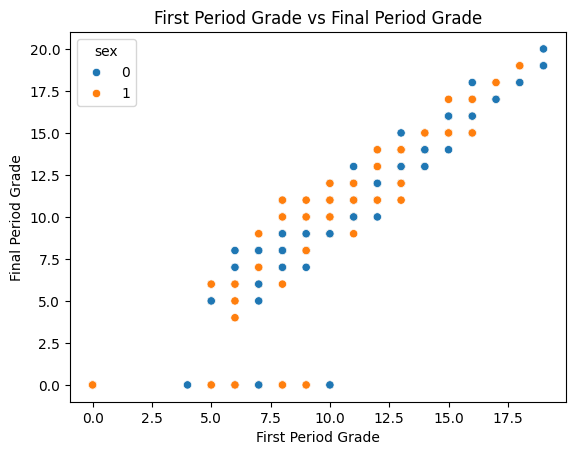

In [84]:
sns.scatterplot(data= df, x="G2", y="G3", color="pink", hue="sex")
plt.xlabel("First Period Grade")
plt.ylabel("Final Period Grade")
plt.title("First Period Grade vs Final Period Grade")

Passed candidates grouped by age

age
15    61
16    77
17    66
18    48
19    11
20     2
21     0
22     0
Name: pass, dtype: int64


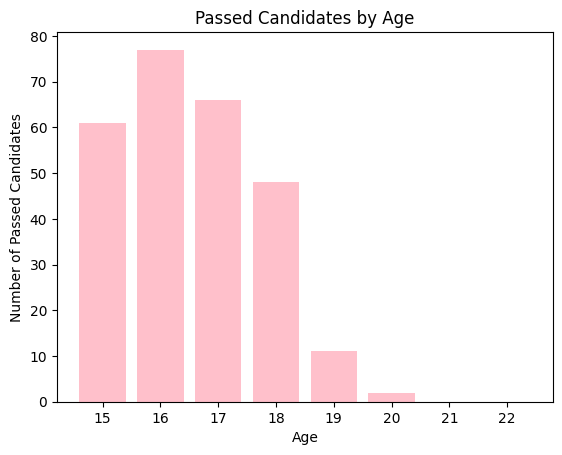

In [85]:
age_groups = df.groupby("age")["pass"].sum()
print(age_groups)
plt.bar(age_groups.index, age_groups.values, color="pink")
plt.xlabel("Age")
plt.ylabel("Number of Passed Candidates")
plt.title("Passed Candidates by Age")
plt.show()

Pass candidates grouped by gender

sex
0    132
1    133
Name: pass, dtype: int64


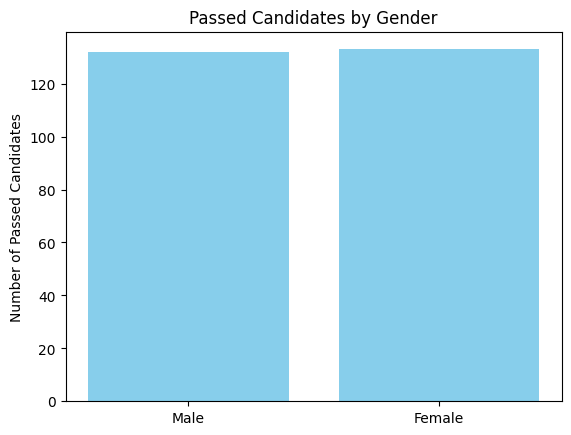

In [86]:
gender_groups = df.groupby("sex")["pass"].sum()
print(gender_groups)
plt.bar(gender_groups.index, gender_groups.values, color="skyblue")
plt.xticks([1, 0], ['Female', 'Male'])
plt.ylabel("Number of Passed Candidates")
plt.title("Passed Candidates by Gender")
plt.show()

Number of passed Candidates grouped by weekly study time

studytime
1     68
2    128
3     49
4     20
Name: pass, dtype: int64


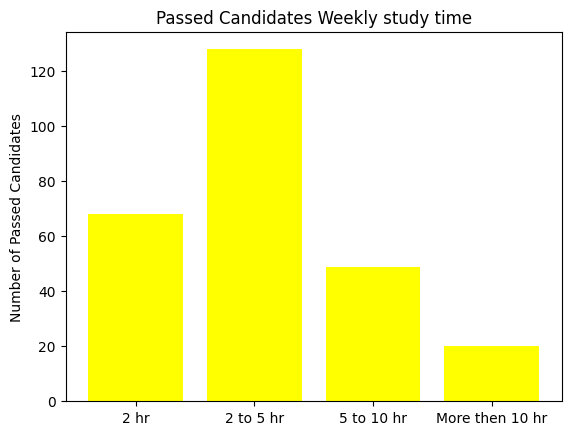

In [87]:
# weekly study time (numeric: 1 - 2 hours, 2 - 2 to 5 hours, 3 - 5 to 10 hours, or 4 - >10 hours)
study_time_groups = df.groupby("studytime")["pass"].sum()
print(study_time_groups)
plt.bar(study_time_groups.index, study_time_groups.values, color="yellow")
plt.xticks([1, 2, 3, 4], ['2 hr', '2 to 5 hr', "5 to 10 hr", "More then 10 hr"])
plt.ylabel("Number of Passed Candidates")
plt.title("Passed Candidates Weekly study time")
plt.show()

Number of passed Candidates grouped by home to school study time

studytime
1     68
2    128
3     49
4     20
Name: pass, dtype: int64


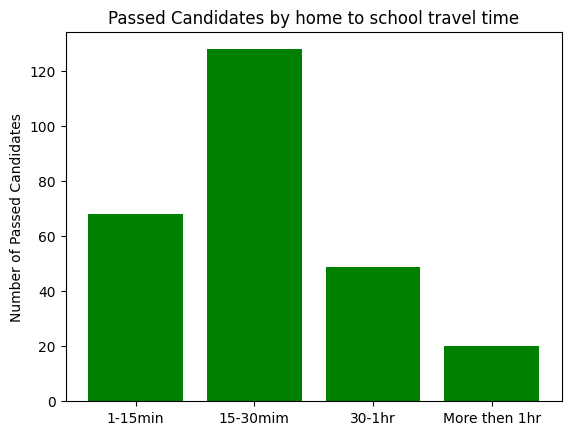

In [88]:
# home to school travel time (numeric: 1 -15 min., 2 - 15 to 30 min., 3 - 30 min. to 1 hour, or 4 - >1 hour)
travel_time_groups = df.groupby("studytime")["pass"].sum()
print(travel_time_groups)
plt.bar(travel_time_groups.index, travel_time_groups.values, color="green")
plt.xticks([1, 2, 3, 4], ['1-15min', '15-30mim', "30-1hr", "More then 1hr"])
plt.ylabel("Number of Passed Candidates")
plt.title("Passed Candidates by home to school travel time")
plt.show()

Number of passed candidated grouped by working father vs mother

Fedu
0     2
1    47
2    77
3    67
4    72
Name: pass, dtype: int64
Medu
0     2
1    34
2    67
3    64
4    98
Name: pass, dtype: int64


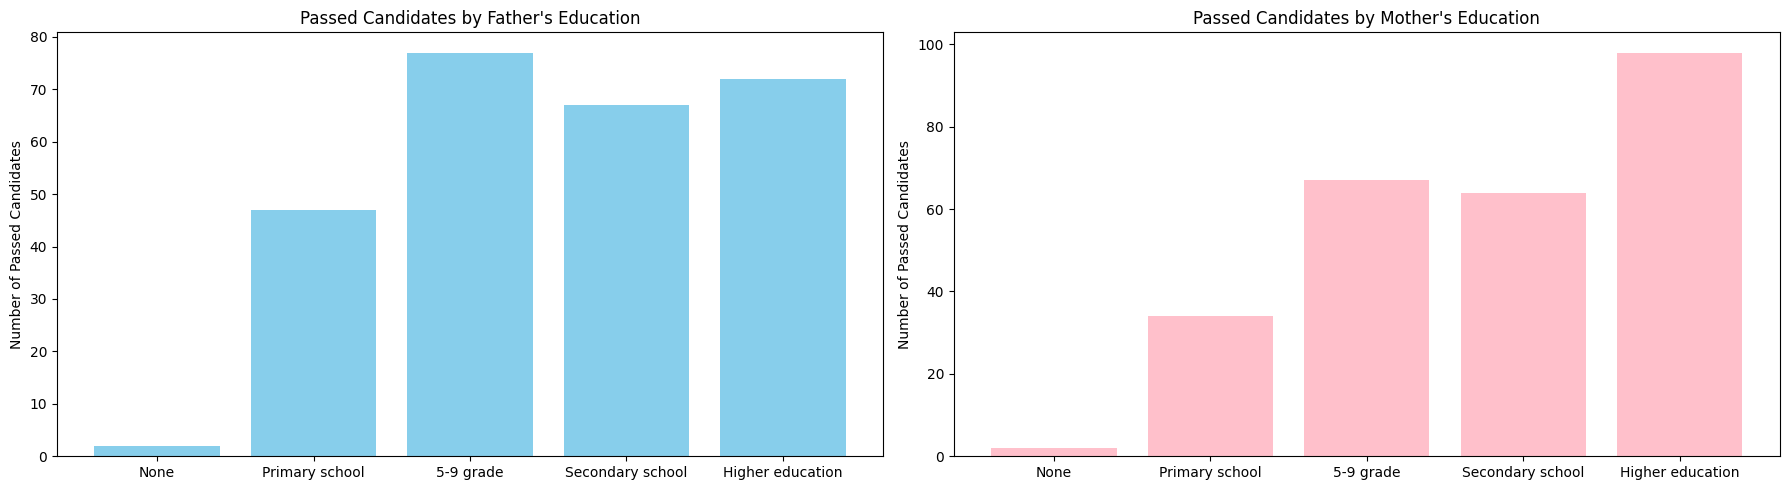

In [89]:
# mother's education (numeric: 0 - none, 1 - primary education (4th grade), 2 - 5th to 9th grade, 3 - secondary education or 4 - higher education)
# father's education (numeric: 0 - none, 1 - primary education (4th grade), 2 - 5th to 9th grade, 3 - secondary education or 4 - higher education)

father_groups = df.groupby("Fedu")["pass"].sum()
print(father_groups)
mother_groups = df.groupby("Medu")["pass"].sum()
print(mother_groups)

figure, axes = plt.subplots(1, 2, figsize=(18, 5))

axes[0].bar(father_groups.index, father_groups.values, color="skyblue")
axes[0].set_xticks([0, 1, 2, 3, 4], ['None', 'Primary school', "5-9 grade", "Secondary school", "Higher education"])
axes[0].set_ylabel("Number of Passed Candidates")
axes[0].set_title("Passed Candidates by Father's Education")


axes[1].bar(mother_groups.index, mother_groups.values, color="pink")
axes[1].set_xticks([0, 1, 2, 3, 4], ['None', 'Primary school', "5-9 grade", "Secondary school", "Higher education"])
axes[1].set_ylabel("Number of Passed Candidates")
axes[1].set_title("Passed Candidates by Mother's Education")

figure.tight_layout()
figure.show()

Getting X (input), Y (prediction)

In [90]:
x = df[df.columns[:-1]]
y = df[df.columns[-1]]

Train, Test Split

In [91]:
x_test, x_train, y_test, y_train = train_test_split(x, y, test_size=0.3, train_size=0.7, random_state=42)

Model

In [92]:
scm = SVC().fit(x_train, y_train)
pre = scm.predict(x_test)

Accuracy and classification report

In [93]:
print("Train score: ", scm.score(x_train, y_train))
print("Test score: ", scm.score(x_test, y_test)) # Means there is no overfitting
print(classification_report(y_test, pre))

Train score:  0.9495798319327731
Test score:  0.9311594202898551
              precision    recall  f1-score   support

           0       0.90      0.87      0.88        84
           1       0.94      0.96      0.95       192

    accuracy                           0.93       276
   macro avg       0.92      0.91      0.92       276
weighted avg       0.93      0.93      0.93       276

